In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
#Step 1: Load the files
df = pd.read_csv("stat-stop-smok-serv-eng-2025-26-q4.csv")
fin = pd.read_csv("stat-stop-smok-serv-finance-eng-2025-26-q4.csv")

In [4]:
numeric_cols = ["Total referred", "Set quit date", "Quit", "Quit (%)"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [5]:
base = df[(df["MonitoringCategoryType"] == "Age band")
          & (df["Sex"] == "All persons")
          & (df["MonitoringCategory"] == "All ages")].copy()

In [6]:
trend_orgs = ["West Sussex", "South East", "England"]

In [7]:
# The finance file has three spend categories, not two. An earlier
# version of this only summed delivery spend + aids cost, which
# understated West Sussex's true cost per quitter by roughly half,
# since "other spend" is over half of West Sussex's total budget.
annual_totals = base[base["OrgName"].isin(trend_orgs)].groupby("OrgName").agg(
    quits=("Quit", "sum")
).reset_index()

fin_slim = fin[fin["OrgName"].isin(trend_orgs)][
    ["OrgName",
     "Allocation for smoking cessation for the year (excluding stop smoking aids)",
     "Total spend on delivery of stop smoking services for the year to date",
     "Total cost of stop smoking aids for the year to date",
     "Other spend on smoking cessation"]
].copy()

fin_slim["total_spend"] = (
    fin_slim["Total spend on delivery of stop smoking services for the year to date"]
    + fin_slim["Total cost of stop smoking aids for the year to date"]
    + fin_slim["Other spend on smoking cessation"]
)
fin_slim["allocation"] = fin_slim["Allocation for smoking cessation for the year (excluding stop smoking aids)"]

# Budget variance and utilisation — this is the new part, and it
# directly answers the advert's ask to monitor spend against
# allocation and flag under/overspend.
fin_slim["variance"] = (fin_slim["total_spend"] - fin_slim["allocation"]).round(0)
fin_slim["utilisation_pct"] = (fin_slim["total_spend"] / fin_slim["allocation"] * 100).round(1)

cost = annual_totals.merge(
    fin_slim[["OrgName", "total_spend", "allocation", "variance", "utilisation_pct"]],
    on="OrgName"
)
cost["cost_per_quitter"] = (cost["total_spend"] / cost["quits"]).round(0)

cost.to_csv("cost_per_quitter_list.csv", index=False)
cost

,OrgName,quits,total_spend,allocation,variance,utilisation_pct,cost_per_quitter
0,England,141062.0,107672906.0,101806974.0,5865932.0,105.8,763.0
1,South East,21349.0,17040578.0,16994686.0,45892.0,100.3,798.0
2,West Sussex,1803.0,1556760.0,1556760.0,0.0,100.0,863.0


## chart: spend as % of allocation

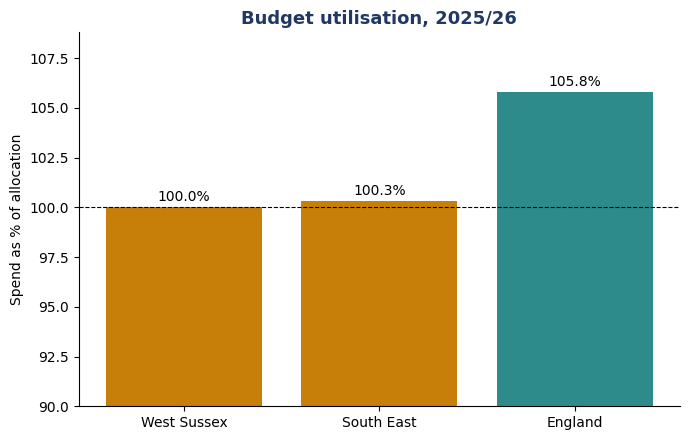

In [10]:
# Show utilisation as a percentage, not raw pounds. West Sussex's
# £1.5m budget next to England's £102m would make West Sussex
# invisible on a linear £ axis — percentage is the fair comparison.
fig, ax = plt.subplots(figsize=(7, 4.5))
areas = ["West Sussex", "South East", "England"]
utilisation = cost.set_index("OrgName").loc[areas, "utilisation_pct"]
colors = ["#C87F0A" if v <= 100.5 else "#2E8B8B" for v in utilisation]

ax.bar(areas, utilisation, color=colors)
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_ylim(90, max(utilisation) + 3)
ax.set_ylabel("Spend as % of allocation")
ax.set_title("Budget utilisation, 2025/26", fontsize=13, color="#1F3864", weight="bold")
for i, v in enumerate(utilisation):
    ax.text(i, v + 0.3, f"{v}%", ha="center", fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("budget_utilisation.png", dpi=150)
plt.show()

Insight: West Sussex spent exactly 100.0% of its allocation, £0 variance. South East was 100.3%. England overspent nationally by 5.8%, £5.9m over its allocation. That's the clearest evidence of budget control in the whole dataset.

In [11]:
# Note: West Sussex reported £0 specifically on stop smoking aids
# (pharmacotherapy), while South East spent £2.99m and England
# £21.48m on that line. This data can't say why — it could be a
# different commissioning route rather than a gap in provision.
# Flag it as an open question, don't draw a conclusion from it.
print(fin[fin["OrgName"].isin(trend_orgs)][
    ["OrgName", "Total cost of stop smoking aids for the year to date"]
])

         OrgName  Total cost of stop smoking aids for the year to date
0        England                                         21480113.0   
8     South East                                          2985491.0   
147  West Sussex                                                0.0   
